In [62]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.cluster import KMeans, DBSCAN

from sklearn.metrics import mean_squared_error, r2_score, silhouette_score




In [63]:
df = pd.read_csv("Q2employee_attrition_performance.csv")

In [64]:
df

,employee_id,age,gender,education,department,job_role,monthly_salary,years_at_company,years_in_current_role,performance_score,...,overtime,distance_from_home_km,num_projects_last_year,training_hours_last_year,num_promotions,last_promotion_years_ago,stock_option_level,relationship_satisfaction,environment_satisfaction,attrition
0,EMP00001,42,Female,Master,Finance,Role_22,107433,2,0,3.4,...,Yes,11,3,21,0,1,0,1,4,No
1,EMP00002,35,Male,Master,HR,Role_8,77660,4,0,3.4,...,Yes,30,4,29,1,2,0,3,3,No
2,EMP00003,40,Male,PhD,Legal,Role_1,114377,3,0,4.1,...,No,10,2,72,0,3,2,4,4,Yes
3,EMP00004,35,Male,High School,R&D,Role_15,79284,2,1,2.9,...,No,9,6,24,0,0,0,3,3,No
4,EMP00005,47,Male,Bachelor,Finance,Role_11,95933,1,1,3.3,...,No,10,2,52,0,0,3,2,3,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,EMP09996,40,Male,High School,Engineering,Role_23,85575,6,2,3.2,...,No,4,10,28,0,1,0,1,4,No
9996,EMP09997,28,Female,PhD,R&D,Role_15,108003,6,2,3.4,...,No,6,4,52,2,0,0,3,2,No
9997,EMP09998,38,Male,Bachelor,Engineering,Role_18,87503,4,1,3.1,...,No,9,6,36,1,0,1,4,3,Yes
9998,EMP09999,34,Female,High School,Engineering,Role_2,79382,0,0,3.4,...,Yes,22,6,38,0,0,0,3,3,No


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   employee_id                10000 non-null  object 
 1   age                        10000 non-null  int64  
 2   gender                     10000 non-null  object 
 3   education                  10000 non-null  object 
 4   department                 10000 non-null  object 
 5   job_role                   10000 non-null  object 
 6   monthly_salary             10000 non-null  int64  
 7   years_at_company           10000 non-null  int64  
 8   years_in_current_role      10000 non-null  int64  
 9   performance_score          10000 non-null  float64
 10  job_satisfaction           10000 non-null  float64
 11  work_life_balance          10000 non-null  int64  
 12  overtime                   10000 non-null  object 
 13  distance_from_home_km      10000 non-null  int6

In [66]:
df.describe()

,age,monthly_salary,years_at_company,years_in_current_role,performance_score,job_satisfaction,work_life_balance,distance_from_home_km,num_projects_last_year,training_hours_last_year,num_promotions,last_promotion_years_ago,stock_option_level,relationship_satisfaction,environment_satisfaction
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,37.848500,85422.334500,3.815100,1.301900,3.435560,3.168380,2.948500,10.618100,4.024900,39.795300,0.395200,0.921400,1.006800,2.902200,2.898700
std,9.501872,18519.436876,4.131588,1.764275,0.525579,0.961153,0.804806,10.212349,1.949477,19.604056,0.650276,1.362721,1.003322,0.940916,0.933555
min,22.000000,38957.000000,0.000000,0.000000,1.400000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,31.000000,72177.750000,1.000000,0.000000,3.100000,2.500000,3.000000,3.000000,3.000000,26.000000,0.000000,0.000000,0.000000,2.000000,2.000000
50%,37.000000,84043.500000,3.000000,1.000000,3.400000,3.200000,3.000000,7.000000,4.000000,40.000000,0.000000,0.000000,1.000000,3.000000,3.000000
75%,45.000000,97020.000000,6.000000,2.000000,3.800000,3.900000,3.000000,14.000000,5.000000,53.000000,1.000000,1.000000,2.000000,4.000000,4.000000
max,65.000000,163489.000000,33.000000,15.000000,5.000000,5.000000,4.000000,107.000000,10.000000,119.000000,4.000000,14.000000,3.000000,4.000000,4.000000


In [67]:
df.head()

,employee_id,age,gender,education,department,job_role,monthly_salary,years_at_company,years_in_current_role,performance_score,...,overtime,distance_from_home_km,num_projects_last_year,training_hours_last_year,num_promotions,last_promotion_years_ago,stock_option_level,relationship_satisfaction,environment_satisfaction,attrition
0,EMP00001,42,Female,Master,Finance,Role_22,107433,2,0,3.4,...,Yes,11,3,21,0,1,0,1,4,No
1,EMP00002,35,Male,Master,HR,Role_8,77660,4,0,3.4,...,Yes,30,4,29,1,2,0,3,3,No
2,EMP00003,40,Male,PhD,Legal,Role_1,114377,3,0,4.1,...,No,10,2,72,0,3,2,4,4,Yes
3,EMP00004,35,Male,High School,R&D,Role_15,79284,2,1,2.9,...,No,9,6,24,0,0,0,3,3,No
4,EMP00005,47,Male,Bachelor,Finance,Role_11,95933,1,1,3.3,...,No,10,2,52,0,0,3,2,3,No


In [68]:
df.tail()

,employee_id,age,gender,education,department,job_role,monthly_salary,years_at_company,years_in_current_role,performance_score,...,overtime,distance_from_home_km,num_projects_last_year,training_hours_last_year,num_promotions,last_promotion_years_ago,stock_option_level,relationship_satisfaction,environment_satisfaction,attrition
9995,EMP09996,40,Male,High School,Engineering,Role_23,85575,6,2,3.2,...,No,4,10,28,0,1,0,1,4,No
9996,EMP09997,28,Female,PhD,R&D,Role_15,108003,6,2,3.4,...,No,6,4,52,2,0,0,3,2,No
9997,EMP09998,38,Male,Bachelor,Engineering,Role_18,87503,4,1,3.1,...,No,9,6,36,1,0,1,4,3,Yes
9998,EMP09999,34,Female,High School,Engineering,Role_2,79382,0,0,3.4,...,Yes,22,6,38,0,0,0,3,3,No
9999,EMP10000,34,Female,PhD,Legal,Role_27,101594,2,2,3.2,...,Yes,1,2,23,0,1,3,4,3,No


In [69]:
df.shape

(10000, 22)

In [70]:
df.isnull().sum()

employee_id                  0
age                          0
gender                       0
education                    0
department                   0
job_role                     0
monthly_salary               0
years_at_company             0
years_in_current_role        0
performance_score            0
job_satisfaction             0
work_life_balance            0
overtime                     0
distance_from_home_km        0
num_projects_last_year       0
training_hours_last_year     0
num_promotions               0
last_promotion_years_ago     0
stock_option_level           0
relationship_satisfaction    0
environment_satisfaction     0
attrition                    0
dtype: int64

In [71]:
df.duplicated().sum()

np.int64(0)

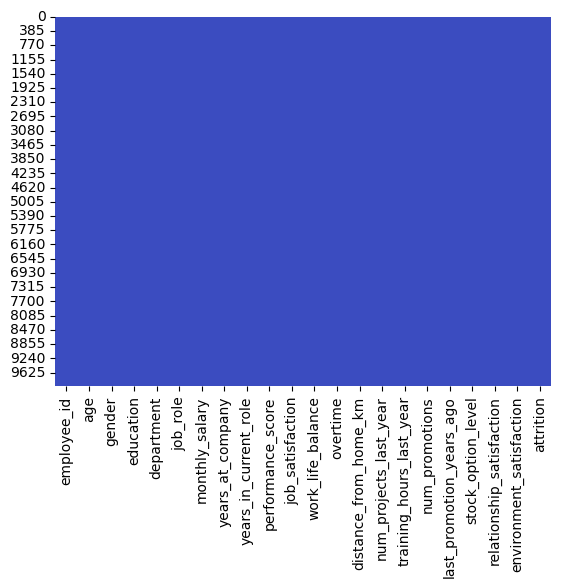

In [72]:

sns.heatmap(df.isnull(), cbar=False, cmap='coolwarm')
plt.show()


In [73]:
# Missing Handling

num_cols = df.select_dtypes(include=['number']).columns

cat_cols = df.select_dtypes(include=['object']).columns

num_imp = SimpleImputer(strategy='mean')

cat_imp = SimpleImputer(strategy='most_frequent')

df[num_cols] = num_imp.fit_transform(df[num_cols])

df[cat_cols] = cat_imp.fit_transform(df[cat_cols])


In [74]:
df

,employee_id,age,gender,education,department,job_role,monthly_salary,years_at_company,years_in_current_role,performance_score,...,overtime,distance_from_home_km,num_projects_last_year,training_hours_last_year,num_promotions,last_promotion_years_ago,stock_option_level,relationship_satisfaction,environment_satisfaction,attrition
0,EMP00001,42.0,Female,Master,Finance,Role_22,107433.0,2.0,0.0,3.4,...,Yes,11.0,3.0,21.0,0.0,1.0,0.0,1.0,4.0,No
1,EMP00002,35.0,Male,Master,HR,Role_8,77660.0,4.0,0.0,3.4,...,Yes,30.0,4.0,29.0,1.0,2.0,0.0,3.0,3.0,No
2,EMP00003,40.0,Male,PhD,Legal,Role_1,114377.0,3.0,0.0,4.1,...,No,10.0,2.0,72.0,0.0,3.0,2.0,4.0,4.0,Yes
3,EMP00004,35.0,Male,High School,R&D,Role_15,79284.0,2.0,1.0,2.9,...,No,9.0,6.0,24.0,0.0,0.0,0.0,3.0,3.0,No
4,EMP00005,47.0,Male,Bachelor,Finance,Role_11,95933.0,1.0,1.0,3.3,...,No,10.0,2.0,52.0,0.0,0.0,3.0,2.0,3.0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,EMP09996,40.0,Male,High School,Engineering,Role_23,85575.0,6.0,2.0,3.2,...,No,4.0,10.0,28.0,0.0,1.0,0.0,1.0,4.0,No
9996,EMP09997,28.0,Female,PhD,R&D,Role_15,108003.0,6.0,2.0,3.4,...,No,6.0,4.0,52.0,2.0,0.0,0.0,3.0,2.0,No
9997,EMP09998,38.0,Male,Bachelor,Engineering,Role_18,87503.0,4.0,1.0,3.1,...,No,9.0,6.0,36.0,1.0,0.0,1.0,4.0,3.0,Yes
9998,EMP09999,34.0,Female,High School,Engineering,Role_2,79382.0,0.0,0.0,3.4,...,Yes,22.0,6.0,38.0,0.0,0.0,0.0,3.0,3.0,No


In [75]:
# Label Encoding 
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

df.head()


,employee_id,age,gender,education,department,job_role,monthly_salary,years_at_company,years_in_current_role,performance_score,...,overtime,distance_from_home_km,num_projects_last_year,training_hours_last_year,num_promotions,last_promotion_years_ago,stock_option_level,relationship_satisfaction,environment_satisfaction,attrition
0,0,42.0,0,2,1,14,107433.0,2.0,0.0,3.4,...,1,11.0,3.0,21.0,0.0,1.0,0.0,1.0,4.0,0
1,1,35.0,1,2,2,47,77660.0,4.0,0.0,3.4,...,1,30.0,4.0,29.0,1.0,2.0,0.0,3.0,3.0,0
2,2,40.0,1,3,3,0,114377.0,3.0,0.0,4.1,...,0,10.0,2.0,72.0,0.0,3.0,2.0,4.0,4.0,1
3,3,35.0,1,1,6,6,79284.0,2.0,1.0,2.9,...,0,9.0,6.0,24.0,0.0,0.0,0.0,3.0,3.0,0
4,4,47.0,1,0,1,2,95933.0,1.0,1.0,3.3,...,0,10.0,2.0,52.0,0.0,0.0,3.0,2.0,3.0,0


In [38]:
# EDA 

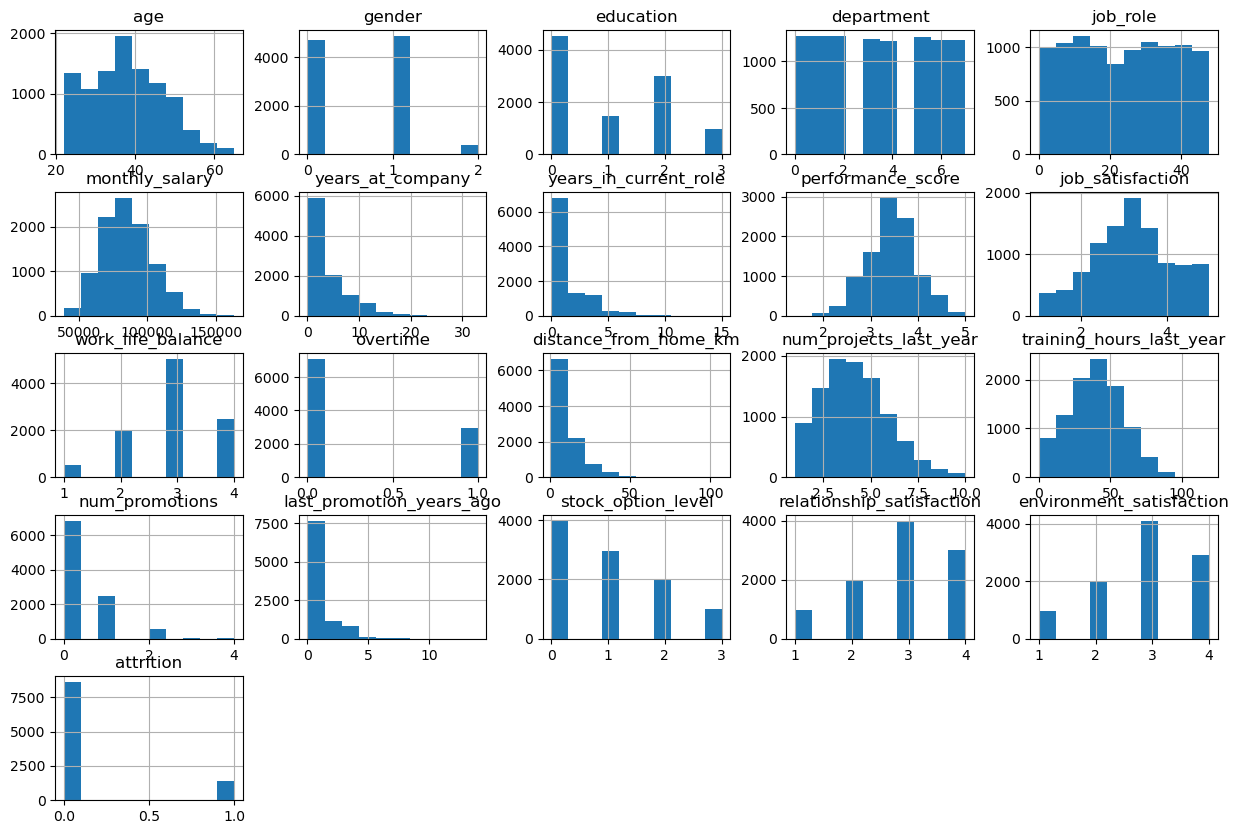

In [39]:
df.hist(figsize=(15,10))
plt.show()

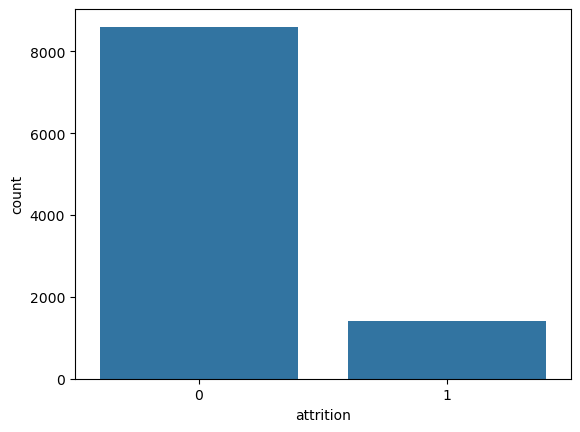

In [40]:

sns.countplot(x=df["attrition"], data=df)
plt.show()


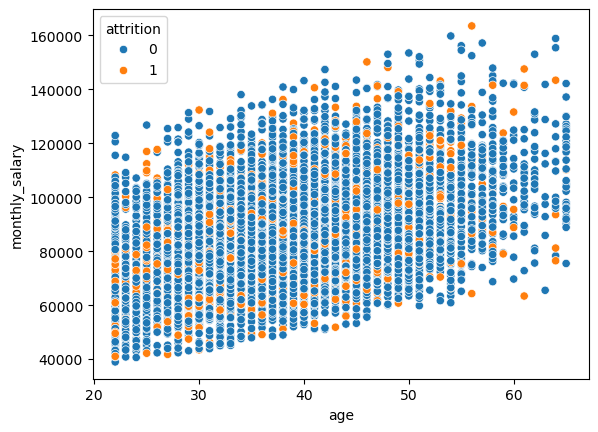

In [41]:
sns.scatterplot(x=df[num_cols[0]], y=df[num_cols[1]], hue=df[df.columns[-1]])
plt.show()


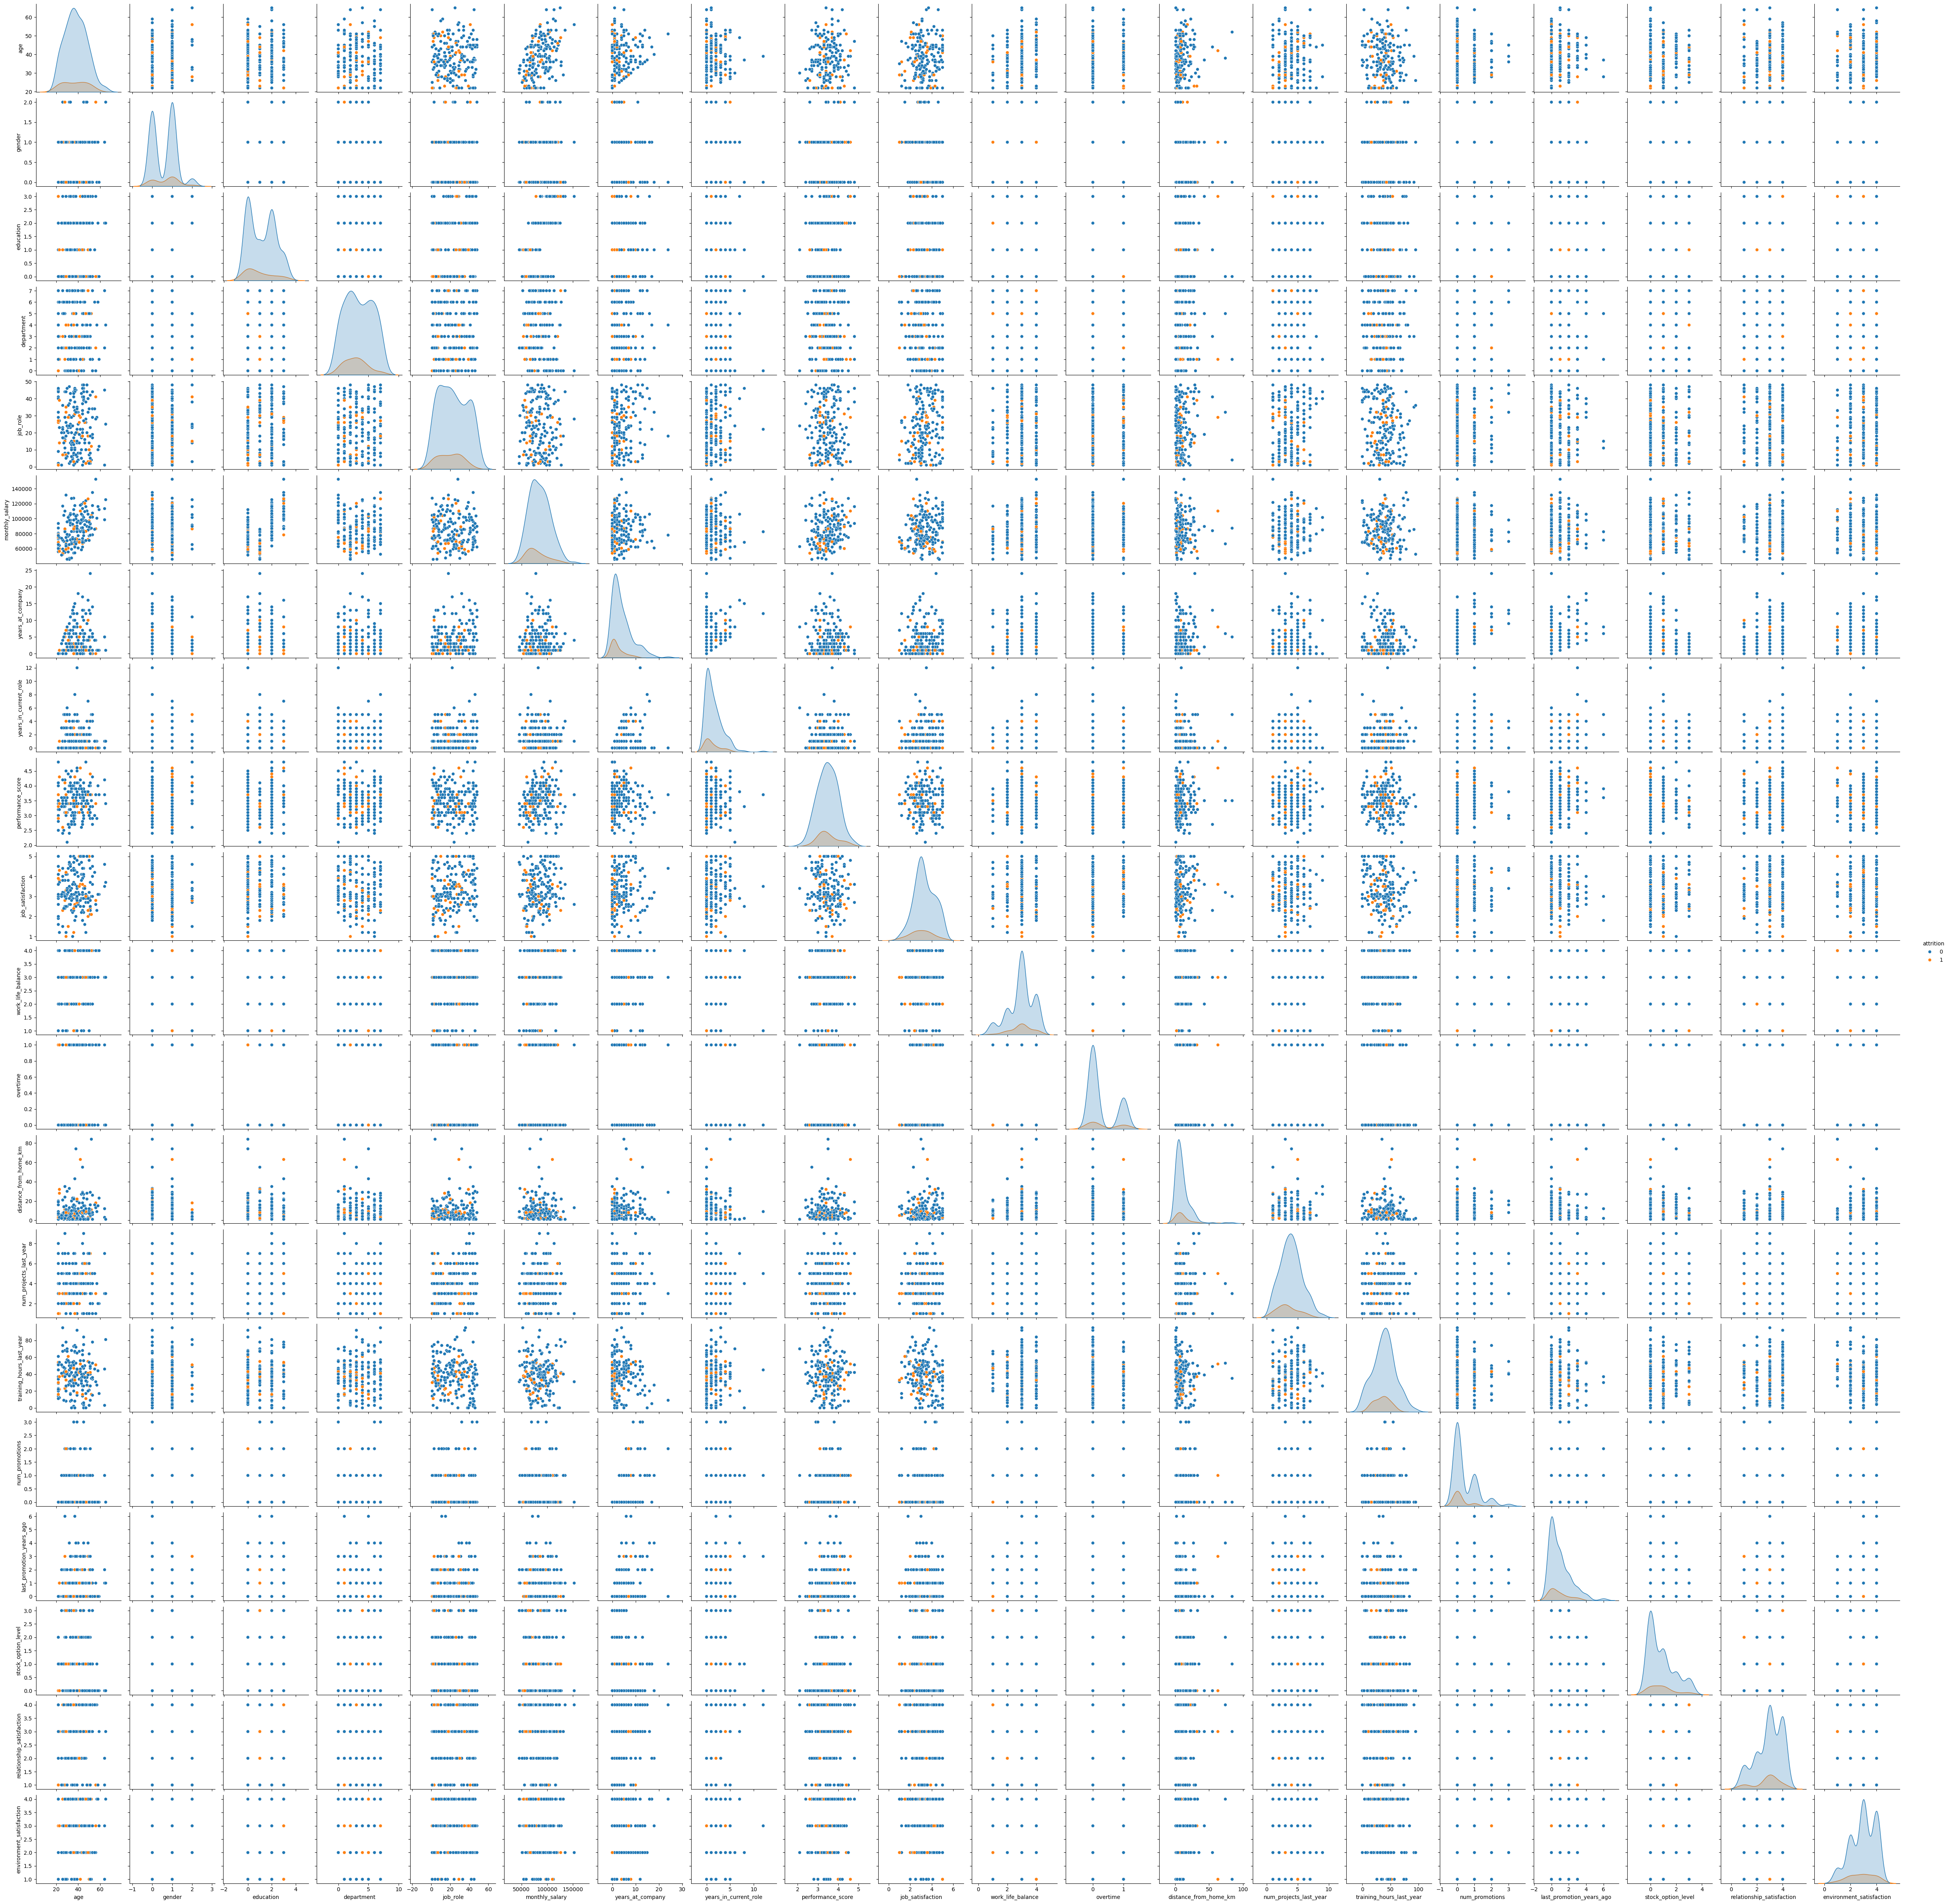

In [59]:

sns.pairplot(df.sample(200), hue=df.columns[-1])
plt.show()




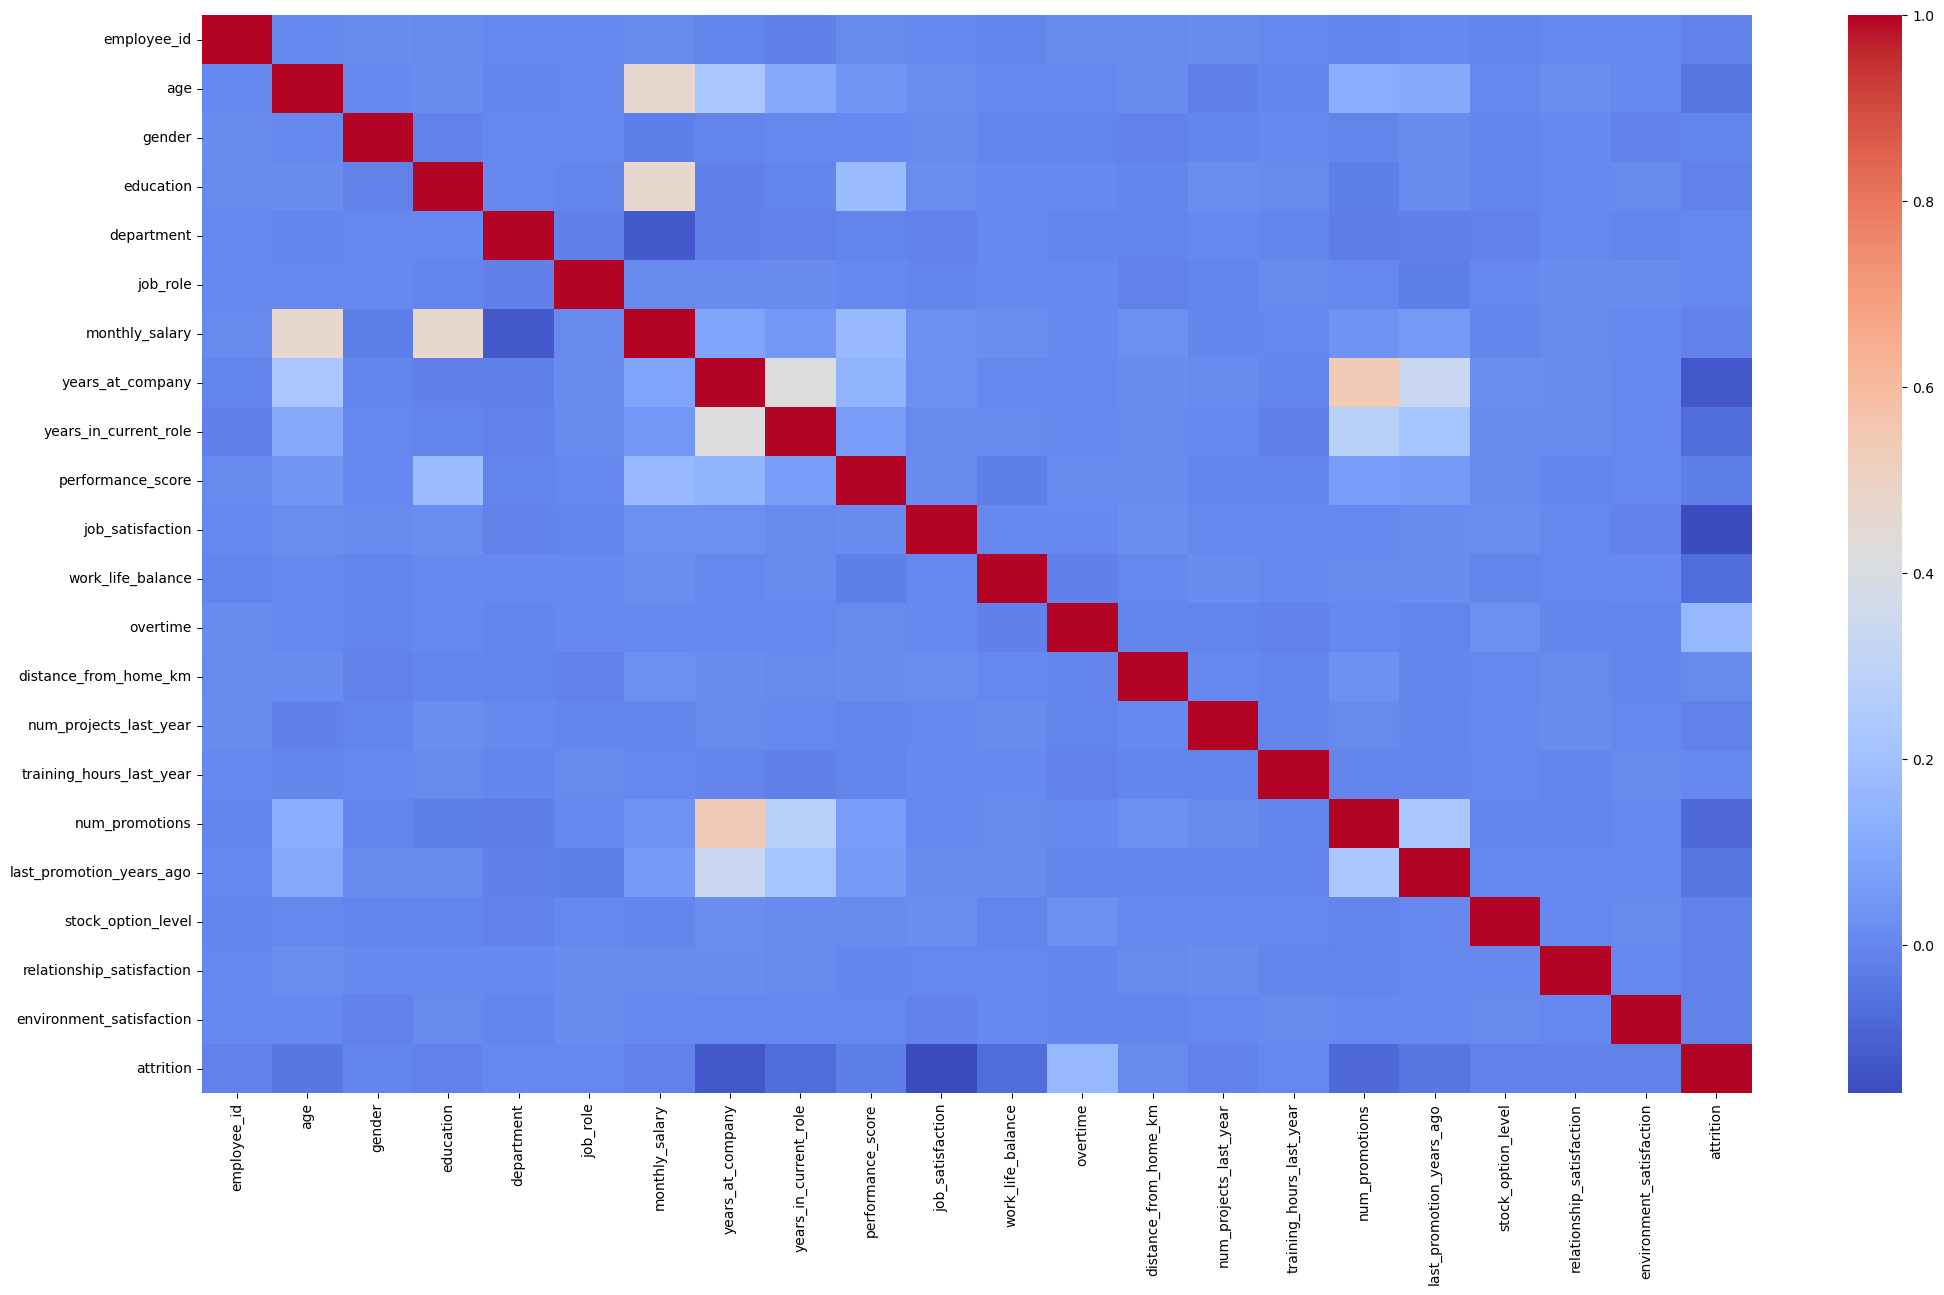

In [81]:

plt.figure(figsize=(25,14))

corr = df.corr()

sns.heatmap(corr, cmap='coolwarm')

plt.show()


In [45]:


# Feature Selection
X = df.drop("attrition", axis=1)

y = df["attrition"]


In [48]:
#Split 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.80, random_state=42
)


In [49]:
#Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


In [50]:
# Linear Regression 


lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)

print("MSE :", mean_squared_error(y_test, y_pred))

print("R2 Score :", r2_score(y_test, y_pred))


MSE : 0.11066667475425757
R2 Score : 0.07530414897970761


In [51]:
#K-Mean Clustring 

kmeans = KMeans(n_clusters=4, random_state=42)

kmeans_cluster = kmeans.fit_predict(X_train_scaled)

print("Silhouette Score :", silhouette_score(X_train_scaled, kmeans_cluster))


Silhouette Score : 0.05105524959522309


In [52]:
#DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5)

db_cluster = dbscan.fit_predict(X_train_scaled)

print("DBSCAN Completed")


DBSCAN Completed


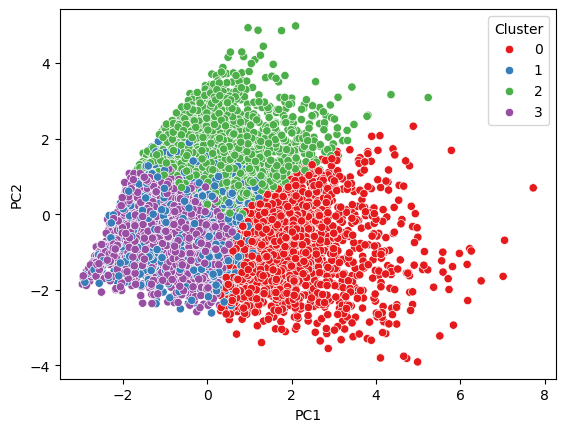

In [90]:
#PCA Dimentionality Reduction
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_train_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1','PC2'])

pca_df['Cluster'] = kmeans_cluster

sns.scatterplot(x='PC1',y='PC2', hue='Cluster', data=pca_df, palette='Set1')

plt.show()


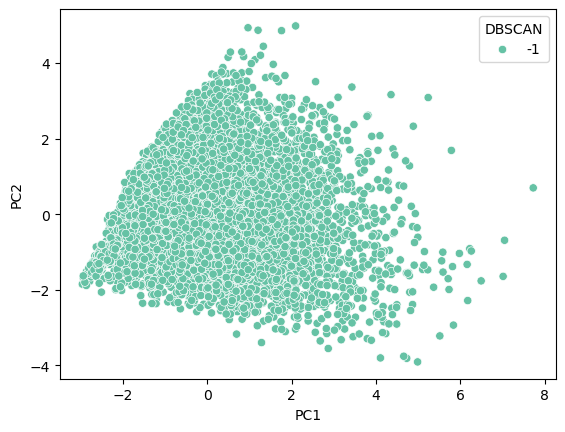

In [84]:

pca_df['DBSCAN'] = db_cluster

sns.scatterplot(x='PC1',y='PC2',hue='DBSCAN',data=pca_df,palette='Set2')
plt.show()


In [56]:
# INSIGHTS

print("Employee with low satisfaction have high attrition")
print("Salary and Overtime has positive correlation with attrition.")



Employee with low satisfaction have high attrition
Salary and Overtime has positive correlation with attrition.


In [57]:
# Importance of preprocessing and scaling 

print("Preproccessing helps us to under stand data clearly and we get information")
print("Scaling help to scale our data we have uneven data so by using scaling we can get all values to their nearby so operation will be perfrom niecely")

Preproccessing helps us to under stand data clearly and we get information
Scaling help to scale our data we have uneven data so by using scaling we can get all values to their nearby so operation will be perfrom niecely


In [ ]:
#Future Improvement 

print("In future we use PCA for dimentionality reduction")
print("Regression identifie important employee relationships")